### Etap 3

Ostatnia część projektu związana jest z opracowaniem modelu regresji (2,5 pkt.), poprzez
zastosowanie poznanych na wykładzie i ćwiczeniach laboratoryjnych metodach doboru cech
(2,5 pkt.) i regularyzacji (2,5 pkt.) oraz opracowanie raportu opisującego przeprowadzone prace,
jak i wyciągnięte wnioski z otrzymanych wyników/zależności (2,5 pkt.).

In [120]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Wczytanie zbioru danych

In [121]:
df = pd.read_csv('data/df_merged_without_outliers.csv')

### Transformacje zmiennych, aby ich rozkład był bardziej podobny do normalnego

Lista atrybutów o rozkładzie prawo skośnym:

In [122]:
right_skewed = np.array(['TotalPop', 'Hispanic', 'Black', 'Native', 'Asian', 'Pacific', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Average_House_Price'], dtype=object)

Lista atrybutów o rozkładzie lewo skośnym:

In [123]:
left_skewed = np.array(['White', 'Drive', 'PrivateWork'], dtype=object)

Wybranie odpowiedniej podstawy logarytmu z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk. Jeżeli logarytmowanie nie pomoże, histogram dla logarytmowanych warotści nie będzie wyświetlany.

<Figure size 1000x2500 with 0 Axes>

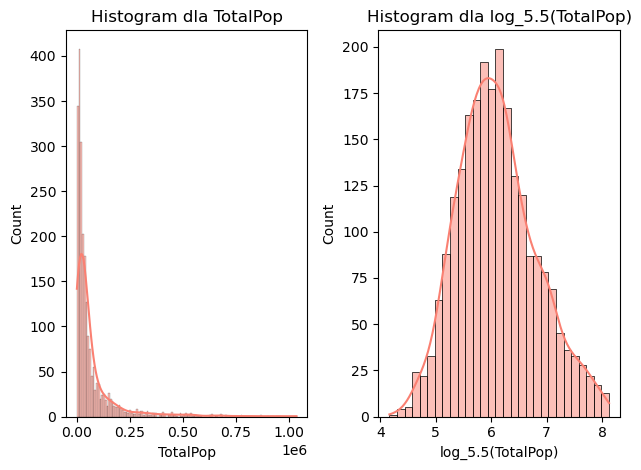

<Figure size 1000x2500 with 0 Axes>

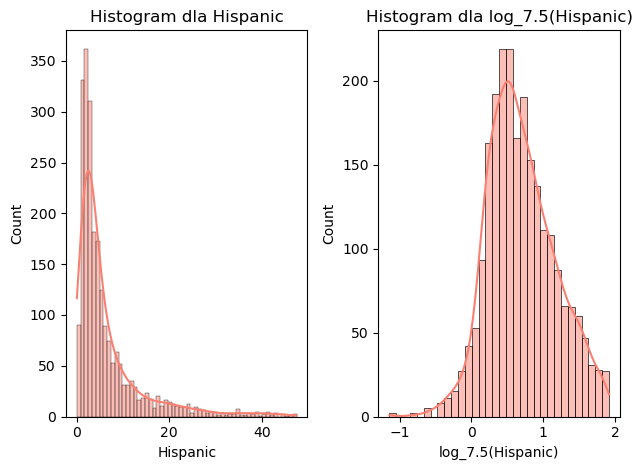

<Figure size 1000x2500 with 0 Axes>

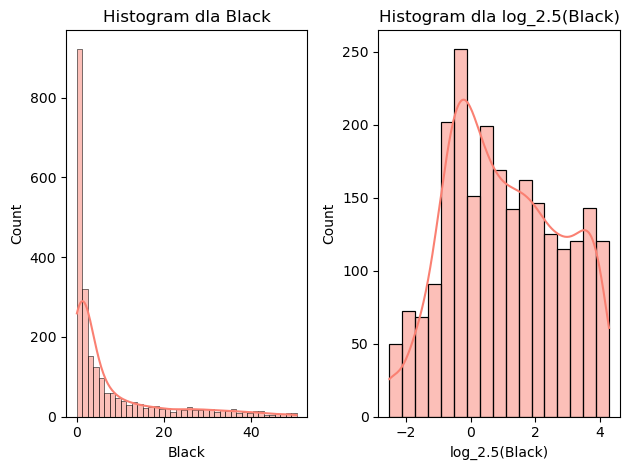

<Figure size 1000x2500 with 0 Axes>

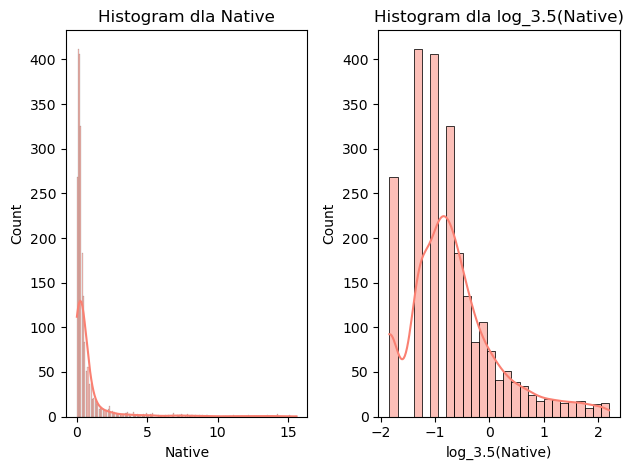

<Figure size 1000x2500 with 0 Axes>

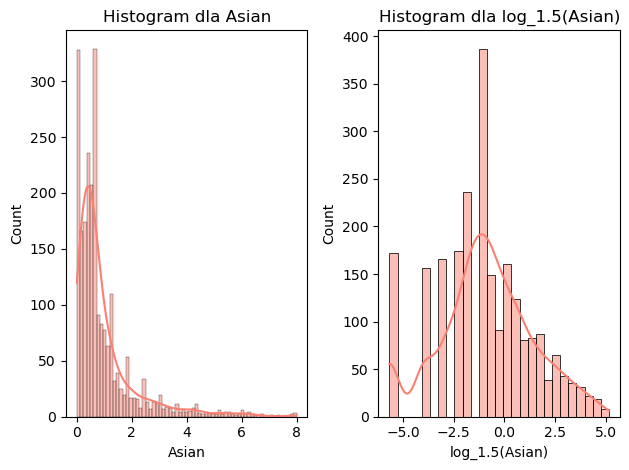

<Figure size 1000x2500 with 0 Axes>

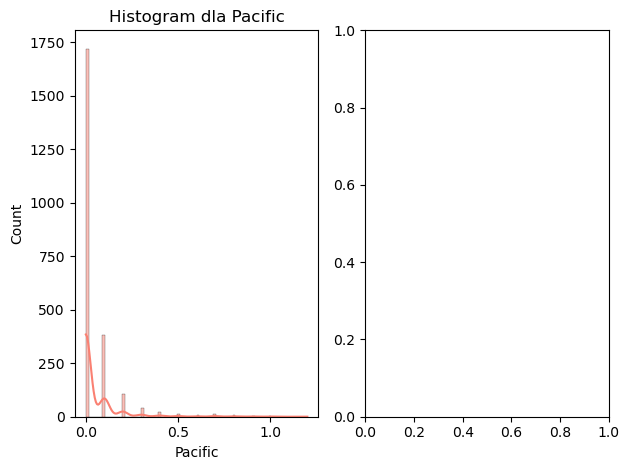

<Figure size 1000x2500 with 0 Axes>

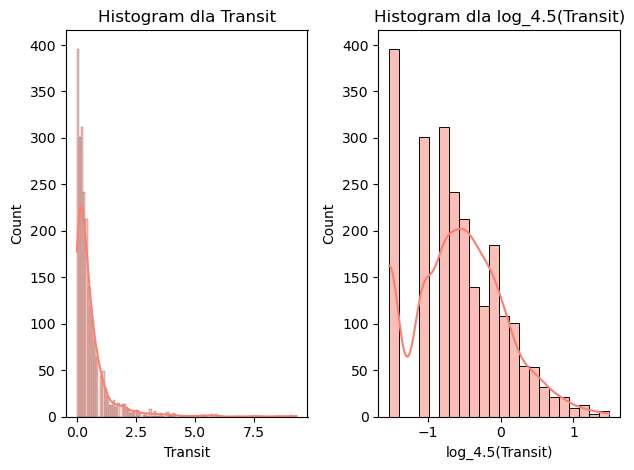

<Figure size 1000x2500 with 0 Axes>

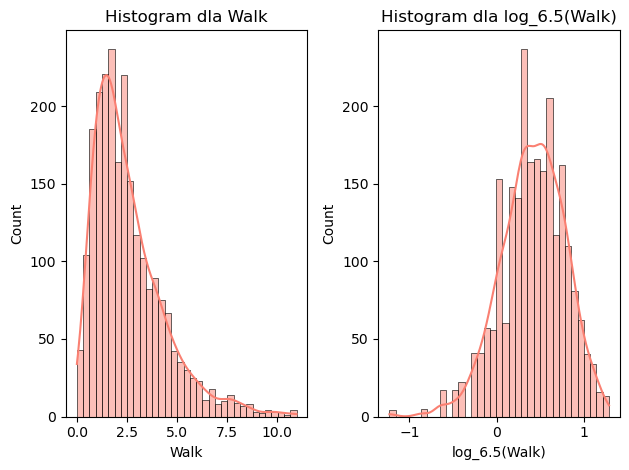

<Figure size 1000x2500 with 0 Axes>

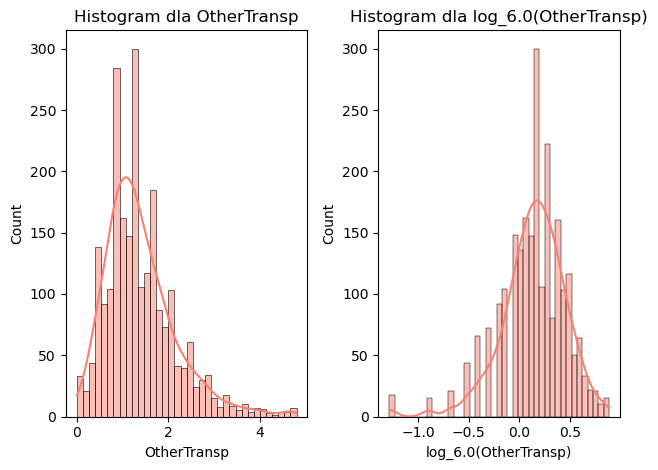

<Figure size 1000x2500 with 0 Axes>

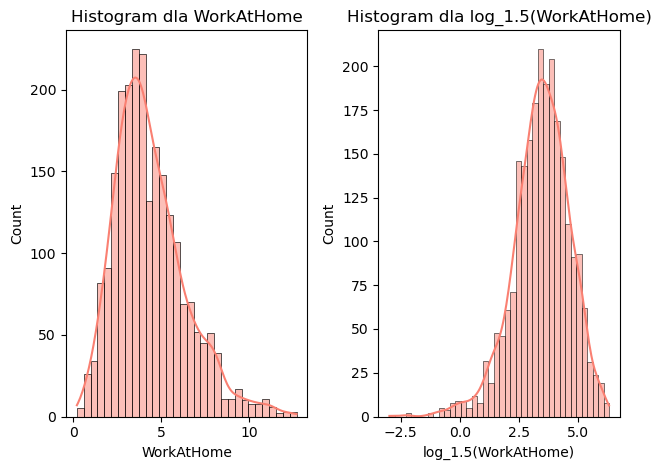

<Figure size 1000x2500 with 0 Axes>

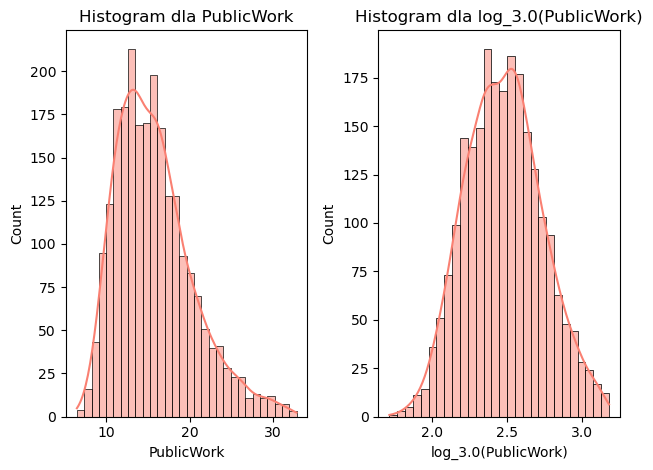

<Figure size 1000x2500 with 0 Axes>

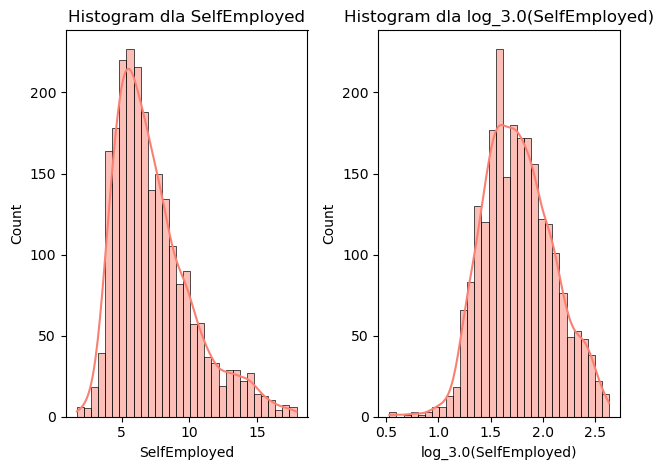

<Figure size 1000x2500 with 0 Axes>

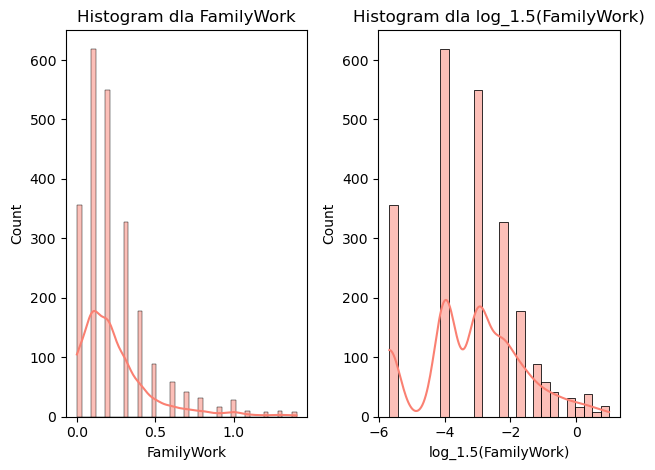

<Figure size 1000x2500 with 0 Axes>

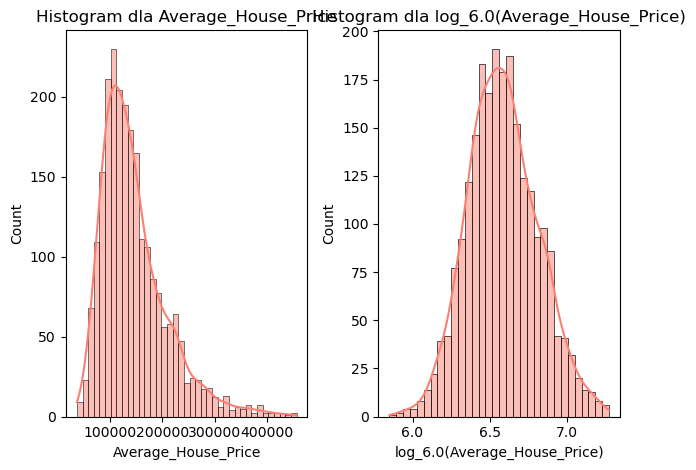

In [124]:
from scripts.right_skewed_to_normal import to_normal

for attr in right_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów poza `Pacifi` logarytmowanie pomogło uzyskać rozkład bardziej zbliżony do normalnego.

Podnoszenie do potęgi, aby z rozkładu prawoskośnego przejsć na bardziej przypominający normalny. Wybranie odpowiedniego wykładnika z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk. Jeżeli podnoszenie do potęgi nie pomoże, histogram dla logarytmowanych warotści nie będzie wyświetlany.

<Figure size 1000x2500 with 0 Axes>

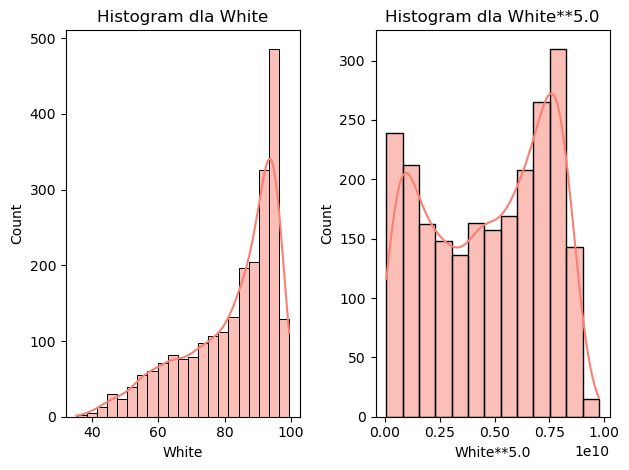

<Figure size 1000x2500 with 0 Axes>

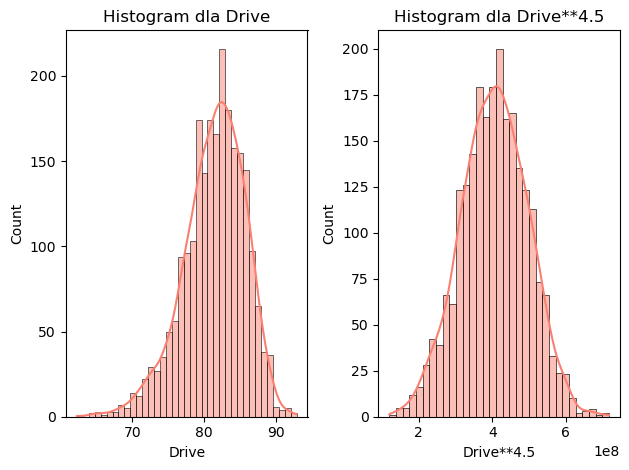

<Figure size 1000x2500 with 0 Axes>

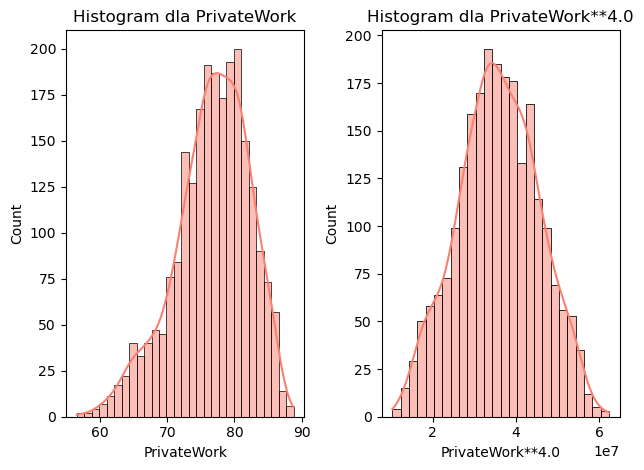

In [125]:
from scripts.left_skewed_to_normal import to_normal

for attr in left_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów z rozkładem prawoskośnym potęgowanie pomogło uzyskać rozkład bardziej normalny, jednakże dla atrybutu `White` zmieniło rokzład z jednomodalnego na dwumodalny

### Macierz korelacji, po dodaniu nowych danych

Spojrzeć na public Work i Private Work, aby usunąć, któryś z tych i podobnie z White i Black

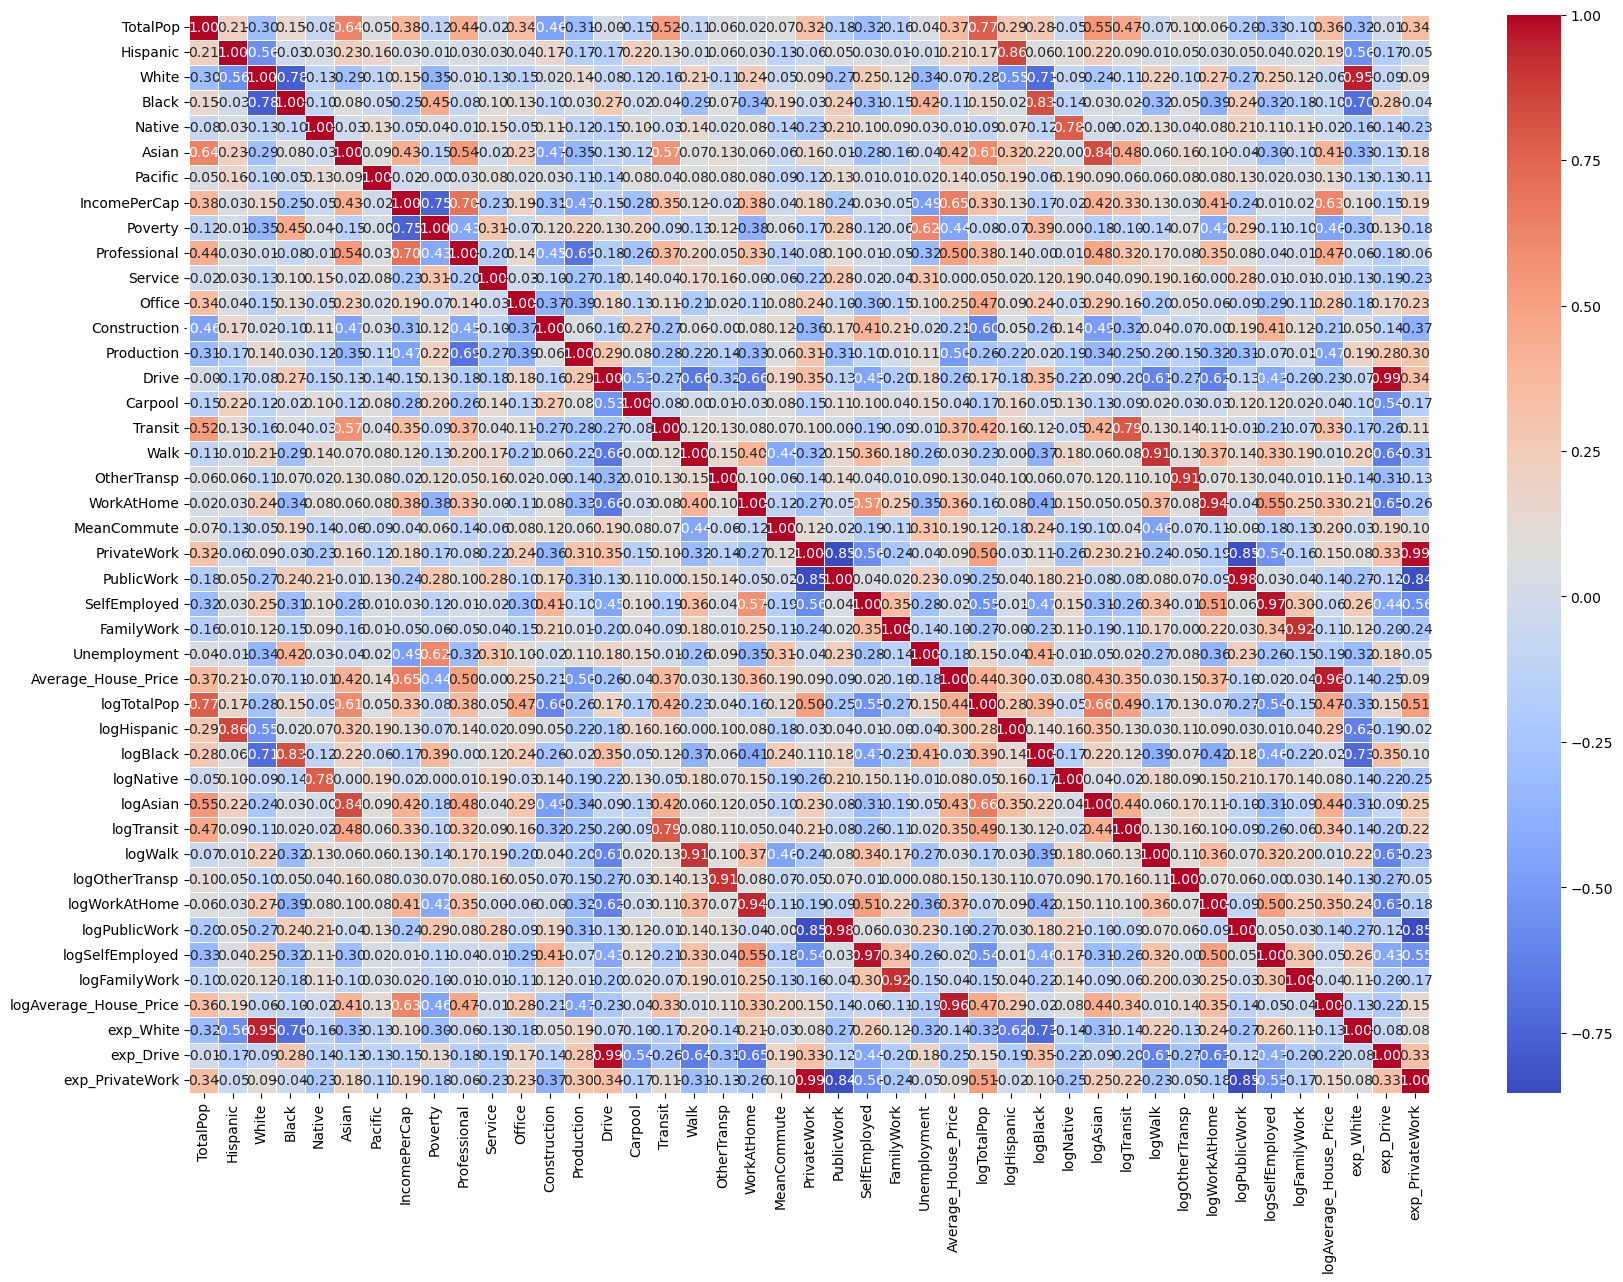

In [126]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Każda z dodanych nowo atrybutów, po przetranformowaniu cech ma wysoką korelację z atrybutem przed transformacją, więc należy usunąć któreś z tych par, także pozbędziemy się danych, które po transformacji mają rozkład bardziej zgodny z normalnym

In [127]:
features = df.columns.tolist()[3:]
left_skewed_list = left_skewed.tolist()
right_skewed_list = right_skewed.tolist()
filtered_features = [attr for attr in features if attr not in left_skewed_list]
filtered_features2 = [attr for attr in filtered_features if attr not in right_skewed_list]

df = df[df.columns.tolist()[:3] + filtered_features2]
display(df.columns.tolist())

['Unnamed: 0',
 'State',
 'County',
 'IncomePerCap',
 'Poverty',
 'Professional',
 'Service',
 'Office',
 'Construction',
 'Production',
 'Carpool',
 'MeanCommute',
 'Unemployment',
 'logTotalPop',
 'logHispanic',
 'logBlack',
 'logNative',
 'logAsian',
 'logTransit',
 'logWalk',
 'logOtherTransp',
 'logWorkAtHome',
 'logPublicWork',
 'logSelfEmployed',
 'logFamilyWork',
 'logAverage_House_Price',
 'exp_White',
 'exp_Drive',
 'exp_PrivateWork']

### Macierz korelacji, po usunięciu elemntów które można było przetransformować

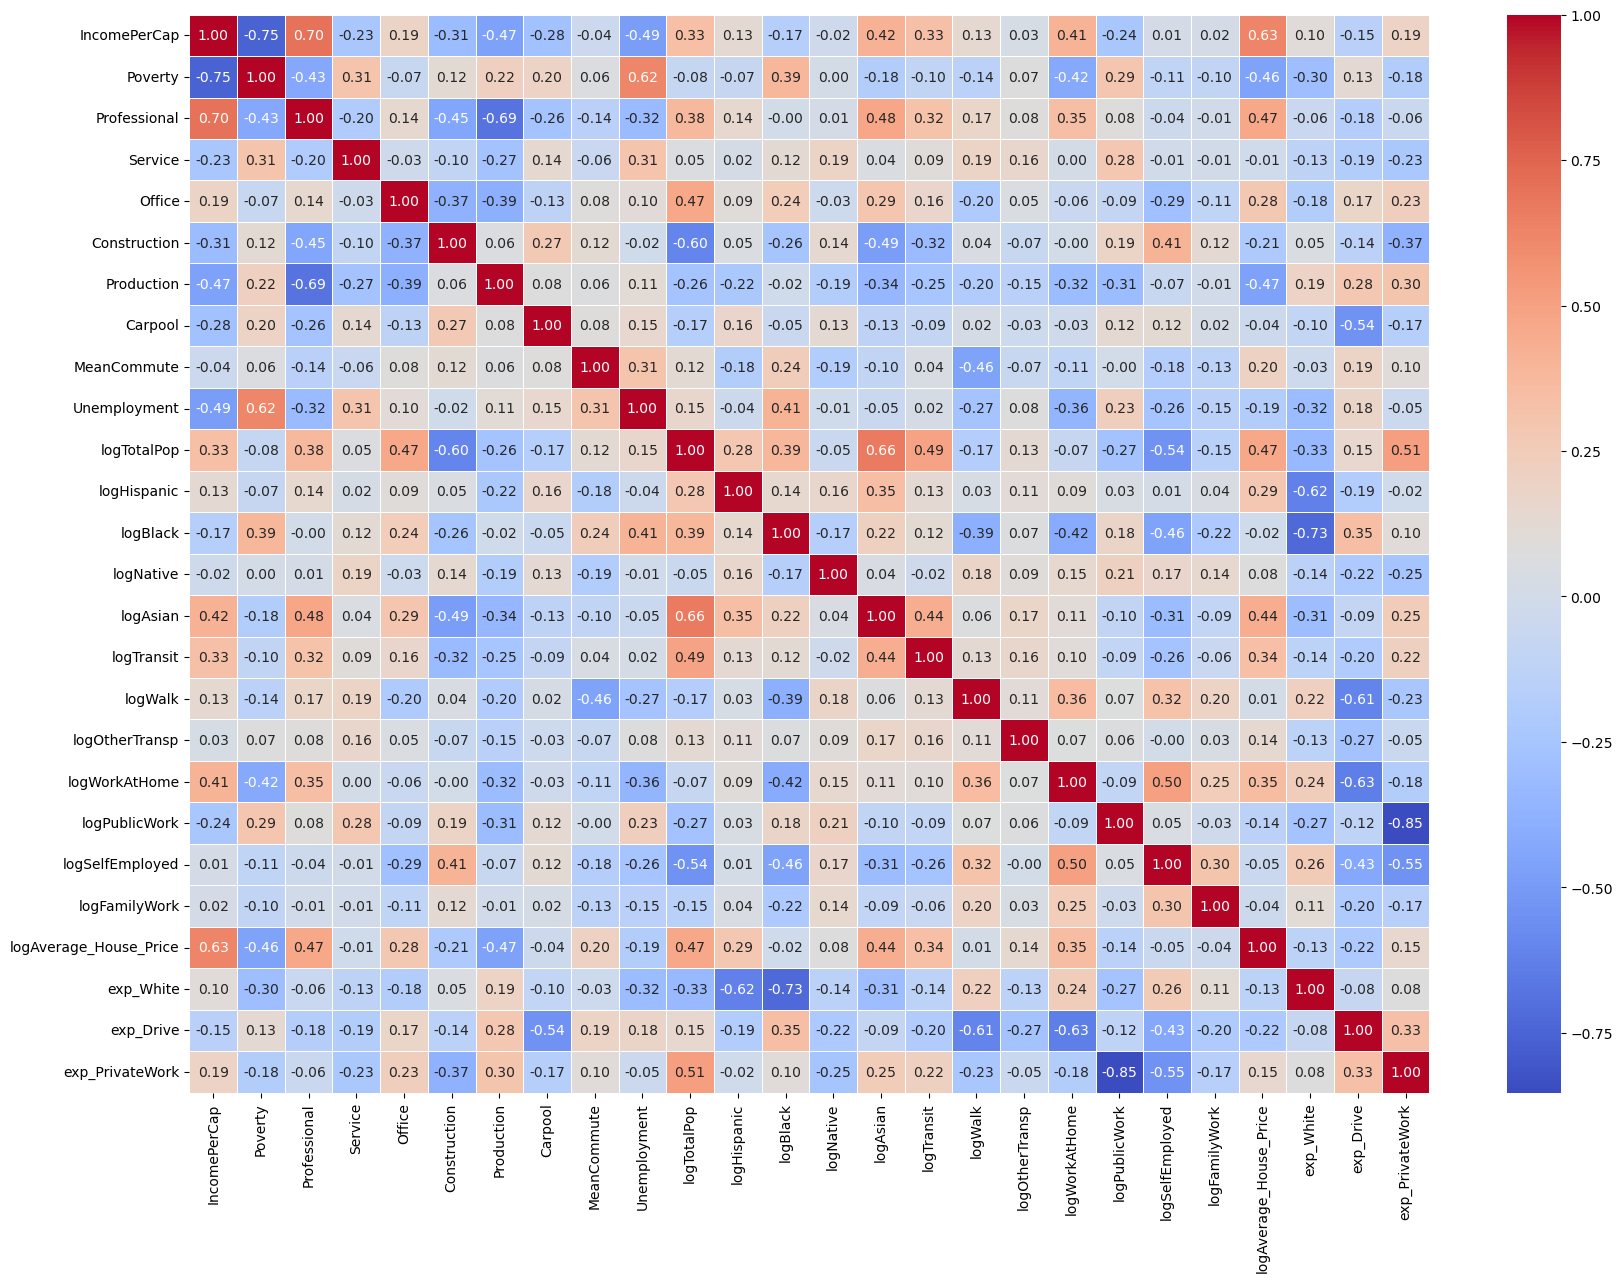

In [128]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Przetransformowane atrybuty `logPublicWork` i `exp_PrivateWork` mają wysoką korelację (-0,85), więc należy jeden z nich usunąć. Usuniemy ten z mniejszą korelacją z atrybutem decyzyjnym, czyli `exp_PrivateWork`.

Podobnie sytuacją wygląda z atrybutami:
 - `logBlack` i `exp_White` (korelacja 0,73), dlatego usuniemy `exp_White`.
 - `Production` i `Professional` (korelacja 0,69), dlatego usuniemy `Production`


In [129]:
df.drop(columns = ['exp_PrivateWork', 'exp_White', 'Production'], inplace=True)

In [130]:
df

,Unnamed: 0,State,County,IncomePerCap,Poverty,Professional,Service,Office,Construction,Carpool,...,logAsian,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,0,Alabama,Autauga County,27824,13.7,35.3,18.0,23.2,8.1,9.6,...,0.000000,-1.070050,-0.190552,0.187789,2.356581,2.740385,1.584241,-3.969362,6.707548,5.099342e+08
1,1,Alabama,Baldwin County,29364,11.8,35.7,18.2,25.6,9.7,7.6,...,-0.550340,-1.070050,-0.056288,0.101756,4.292518,2.334718,1.689675,-3.969362,6.866816,4.761912e+08
2,2,Alabama,Barbour County,17561,27.2,25.0,16.8,22.6,11.5,11.1,...,-0.879669,-0.609205,0.444977,0.328050,0.829843,2.689675,1.717685,-2.259851,6.440511,4.442108e+08
3,3,Alabama,Bibb County,20911,15.2,24.4,17.6,19.7,15.9,9.5,...,-5.678874,-0.148359,-0.489523,0.328050,1.159172,2.605288,1.689675,-2.259851,6.597469,5.206819e+08
4,4,Alabama,Blount County,22021,15.6,28.5,12.9,23.3,15.8,10.2,...,-3.969362,-1.070050,-0.370310,-0.386853,1.944575,2.261860,1.284336,-3.969362,6.651177,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,2887,Wyoming,Sheridan County,31643,6.8,41.1,17.5,20.2,12.1,10.9,...,-0.550340,-0.800473,0.653795,-0.124539,4.292518,2.821826,1.689675,-2.969362,6.962623,3.561657e+08
2323,2889,Wyoming,Sweetwater County,31700,12.0,27.7,16.1,20.0,20.8,14.4,...,-0.879669,0.660373,0.568816,0.187789,1.159172,2.625859,1.238814,-5.678874,6.854041,3.194315e+08
2324,2891,Wyoming,Uinta County,27115,14.9,30.4,19.4,18.1,16.1,14.9,...,-3.969362,0.813639,0.097404,0.187789,1.829843,2.796886,1.731373,-1.709511,6.773738,3.175833e+08
2325,2892,Wyoming,Washakie County,27345,12.8,32.1,16.3,17.6,18.8,10.2,...,-3.969362,-1.530895,1.039592,0.187789,3.709511,2.817716,1.915265,-2.969362,6.712298,3.139119e+08


In [131]:
df.columns.to_list()

['Unnamed: 0',
 'State',
 'County',
 'IncomePerCap',
 'Poverty',
 'Professional',
 'Service',
 'Office',
 'Construction',
 'Carpool',
 'MeanCommute',
 'Unemployment',
 'logTotalPop',
 'logHispanic',
 'logBlack',
 'logNative',
 'logAsian',
 'logTransit',
 'logWalk',
 'logOtherTransp',
 'logWorkAtHome',
 'logPublicWork',
 'logSelfEmployed',
 'logFamilyWork',
 'logAverage_House_Price',
 'exp_Drive']

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.metrics import (
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Dobór cech dla modelu regresji liniowej przy użyciu metody zachłannej

Do ewaluacji użyliśmy walidacji krzyżowej podzielonego na 5 części zbioru, ponieważ zawiera on dużo danych (> 1000 rekordów).

In [133]:
from scripts.greedy_features import find_best_features

features = df.columns[3:]
find_best_features(df[features], 'IncomePerCap')

['Poverty'] 10218987.616236247

['Poverty', 'Professional'] 6181474.142286185

['Poverty', 'Professional', 'logAverage_House_Price'] 5350340.8122964315

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 5067159.469261656

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 4951472.480056727

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 4866808.40423652

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment'] 4860577.101881792

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork'] 4855520.896381021

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed'] 4848662.475693612

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool

Weryfikacja, czy skalowanie, lub standaryzacja zmiennych zmienia coś 

In [134]:
from sklearn.preprocessing import StandardScaler

std_dev_target = df['IncomePerCap'].std()

df_stantard = df[:]
scaler = StandardScaler()
columns_to_scale = df.columns[3:]
df_stantard[columns_to_scale] = scaler.fit_transform(df_stantard[columns_to_scale])

find_best_features(df_stantard[features], 'IncomePerCap', is_standarized=True, std_dev=std_dev_target)

['Poverty'] 0.43662735635206334

['Poverty', 'Professional'] 0.26411625245702414

['Poverty', 'Professional', 'logAverage_House_Price'] 0.2286043639727941

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 0.2165048560938478

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 0.21156189049316326

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 0.20794444295416886

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment'] 0.20767819768839985

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork'] 0.2074621608632385

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed'] 0.20716912067120075

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTran

In [135]:
from sklearn.preprocessing import MinMaxScaler

min_target = df['IncomePerCap'].min()
max_target = df['IncomePerCap'].max()
range_target = max_target - min_target

df_normalized = df[:]
scaler = MinMaxScaler()
columns_to_scale = df.columns[3:]
df_normalized[columns_to_scale] = scaler.fit_transform(df_normalized[columns_to_scale])

find_best_features(df_normalized[features], 'IncomePerCap', is_normalized=True, range_minmax=range_target)

['Poverty'] 0.009372463008337951

['Poverty', 'Professional'] 0.005669410700089793

['Poverty', 'Professional', 'logAverage_House_Price'] 0.004907127127307205

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 0.004647404074308482

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 0.004541300410463497

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 0.004463649771421794

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment'] 0.004457934660198775

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork'] 0.004453297302683708

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed'] 0.00444700702260878

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork

Ani dodatkowa standaryzacja, ani normamlizacja, nie mają praktycznie żadnego wpływu na błąd modelu.

In [136]:
# Cechy, dla których błąd był najmniejszy:
best_features = ['Poverty', 'Professional', 'logAverage_House_Price'] 

### Model regresji liniowej

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.metrics import (
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [137]:
y = df['IncomePerCap']
x = df[best_features]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
features = x_train.columns.values
features

array(['Poverty', 'Professional', 'logAverage_House_Price'], dtype=object)

Uzyćie standrayzacji danych, aby bezpośrednio porównać, który z atrybutów opisującyh ma największy wpływ na atrybut decyzyjny.

In [138]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [139]:
regresor = LinearRegression()
regresor.fit(x_train, y_train)
y_pred_train = regresor.predict(x_train)
y_pred_test = regresor.predict(x_test)
print('Multiple Linear Regression')
e_train= mean_squared_error(y_train, y_pred_train)
e_test = mean_squared_error(y_test, y_pred_test)
print('Mean Squared Error for train:', e_train)
print('Mean Squared Error for test:', e_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print('R2 Score for train:', r2_train)
print('R2 Score for test:', r2_test)



Multiple Linear Regression
Mean Squared Error for train: 5356242.077496819
Mean Squared Error for test: 5003564.010389077
R2 Score for train: 0.7699982006278097
R2 Score for test: 0.790327002409661


/tmp/ipykernel_17135/3185005997.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")


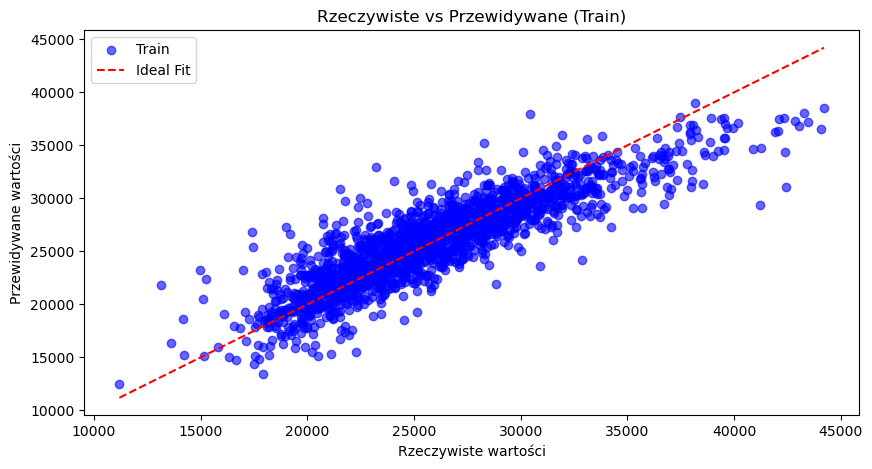

/tmp/ipykernel_17135/3185005997.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


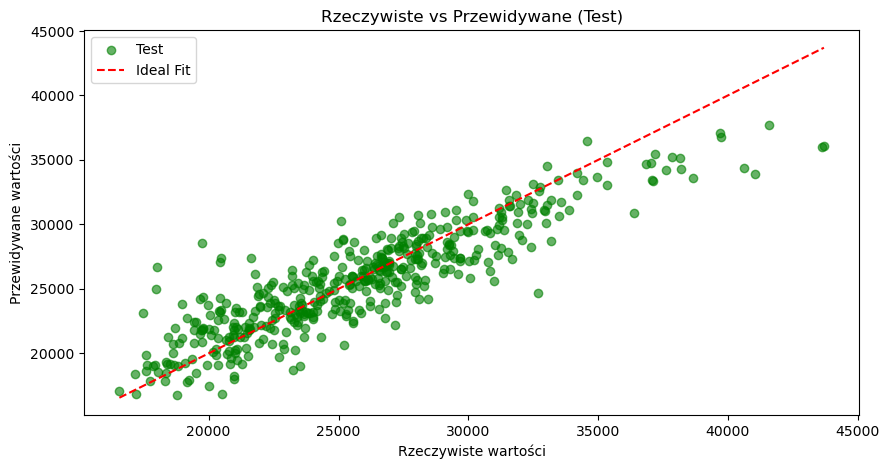

In [140]:
# Dla zbioru treningowego
plt.figure(figsize=(10, 5))
plt.scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
plt.xlabel("Rzeczywiste wartości")
plt.ylabel("Przewidywane wartości")
plt.title("Rzeczywiste vs Przewidywane (Train)")
plt.legend()
plt.show()

# Dla zbioru testowego
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
plt.xlabel("Rzeczywiste wartości")
plt.ylabel("Przewidywane wartości")
plt.title("Rzeczywiste vs Przewidywane (Test)")
plt.legend()
plt.show()

In [141]:

intercept = regresor.intercept_
print("Wyraz wolny (Intercept):", intercept)

coefficients = regresor.coef_
for idx, coef in enumerate(coefficients):
    print(f"{idx} współczynnik: {coef}")


Wyraz wolny (Intercept): 25913.005373455133
0 współczynnik: -2313.1064604815087
1 współczynnik: 1837.2142767381965
2 współczynnik: 1102.469519300168


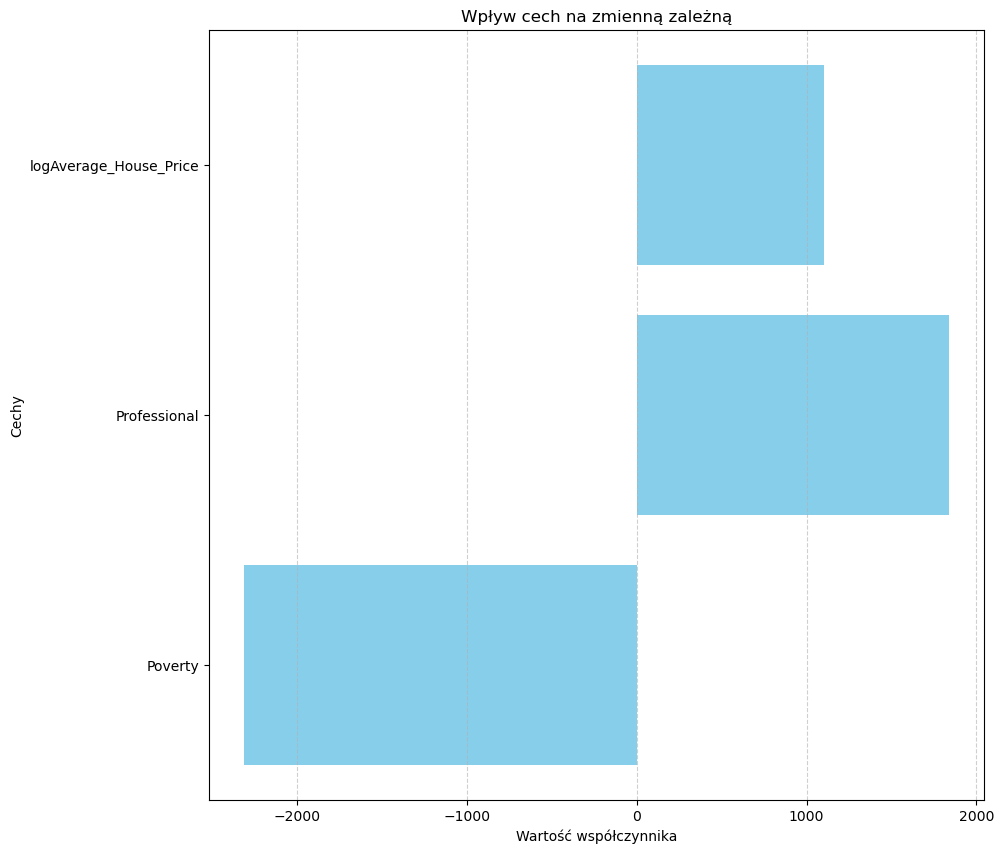

In [142]:
feature_names = x.columns 
coefficients = regresor.coef_


plt.figure(figsize=(10, 10))
plt.barh(feature_names, coefficients, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [143]:
poly_regresor = PolynomialFeatures(degree=4)
x_poly = poly_regresor.fit_transform(x_train)

moznaby dla roznych stopni wielomianu, ale idk czy jest sens sie nad tym tak rozwodzic czy lepiej skupic sie na innych modelach

### Regularyzacja

In [144]:
df.iloc[:, 3:]

,IncomePerCap,Poverty,Professional,Service,Office,Construction,Carpool,MeanCommute,Unemployment,logTotalPop,...,logAsian,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,27824,13.7,35.3,18.0,23.2,8.1,9.6,25.8,5.2,6.403152,...,0.000000,-1.070050,-0.190552,0.187789,2.356581,2.740385,1.584241,-3.969362,6.707548,5.099342e+08
1,29364,11.8,35.7,18.2,25.6,9.7,7.6,27.0,5.5,7.169821,...,-0.550340,-1.070050,-0.056288,0.101756,4.292518,2.334718,1.689675,-3.969362,6.866816,4.761912e+08
2,17561,27.2,25.0,16.8,22.6,11.5,11.1,23.4,12.4,5.967797,...,-0.879669,-0.609205,0.444977,0.328050,0.829843,2.689675,1.717685,-2.259851,6.440511,4.442108e+08
3,20911,15.2,24.4,17.6,19.7,15.9,9.5,30.0,8.2,5.880555,...,-5.678874,-0.148359,-0.489523,0.328050,1.159172,2.605288,1.689675,-2.259851,6.597469,5.206819e+08
4,22021,15.6,28.5,12.9,23.3,15.8,10.2,35.0,4.9,6.430544,...,-3.969362,-1.070050,-0.370310,-0.386853,1.944575,2.261860,1.284336,-3.969362,6.651177,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,31643,6.8,41.1,17.5,20.2,12.1,10.9,16.0,3.1,6.046515,...,-0.550340,-0.800473,0.653795,-0.124539,4.292518,2.821826,1.689675,-2.969362,6.962623,3.561657e+08
2323,31700,12.0,27.7,16.1,20.0,20.8,14.4,20.5,5.2,6.278859,...,-0.879669,0.660373,0.568816,0.187789,1.159172,2.625859,1.238814,-5.678874,6.854041,3.194315e+08
2324,27115,14.9,30.4,19.4,18.1,16.1,14.9,19.9,6.4,5.831205,...,-3.969362,0.813639,0.097404,0.187789,1.829843,2.796886,1.731373,-1.709511,6.773738,3.175833e+08
2325,27345,12.8,32.1,16.3,17.6,18.8,10.2,14.3,6.1,5.290197,...,-3.969362,-1.530895,1.039592,0.187789,3.709511,2.817716,1.915265,-2.969362,6.712298,3.139119e+08


/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.84101e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.96341e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.01257e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.74194e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.87874e-18)

[4570323.761825347, 4570323.790780938, 4570323.877592678, 4570324.22445491, 4570325.608833343, 4570331.121900161, 4570352.980446505, 4570438.893960853, 4570770.830560092, 4572011.481076788, 4576369.179095312, 4590079.850431234]
[4943252.338822069, 4943214.660291443, 4943177.070924869, 4943102.159207661, 4942953.40051337, 4942660.115643, 4942090.266761041, 4941015.815132675, 4939115.356836211, 4936216.141464169, 4933400.413736395, 4936045.237518712]
10


/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.1891e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.24296e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.42329e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.11171e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/lib/python3/dist-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.30906e-18):

Text(0.5, 1.0, 'Współczynniki dla kolejnych wartości lambda')

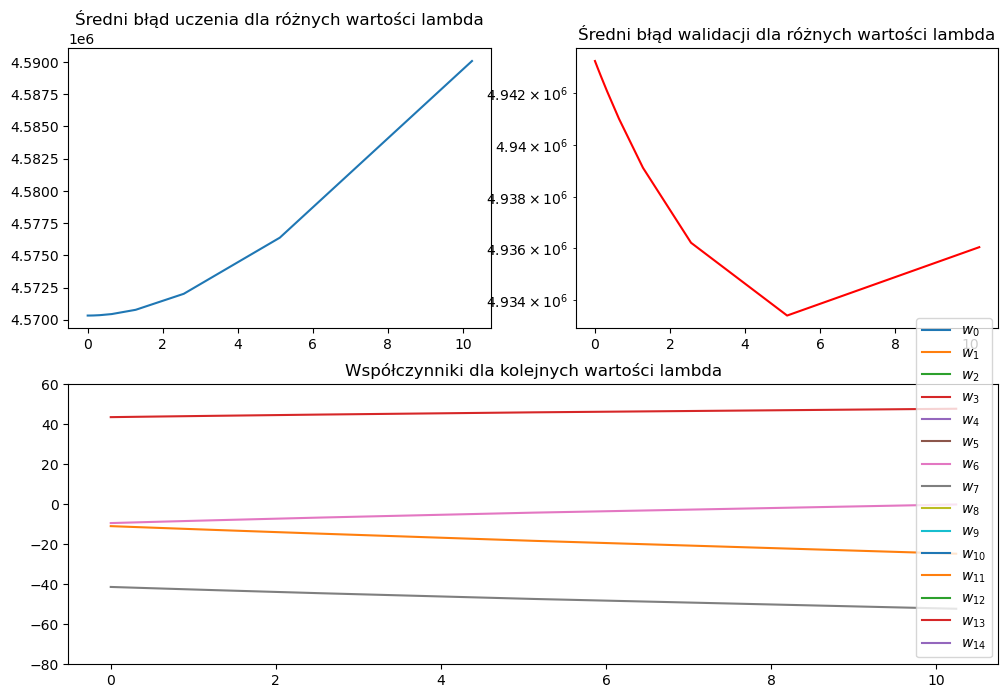

In [148]:
from sklearn.model_selection import cross_validate
import matplotlib.gridspec as gridspec

parameters = [0.01 * 2**i for i in range(11)]
parameters.insert(0, 0)
train_scores = []
test_scores = []
ws = []

for lamb in parameters:
    result = cross_validate(Ridge(alpha = lamb, fit_intercept=True), df.iloc[:, 4:], y, return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
    train_scores.append(np.mean(-result['train_score']))
    test_scores.append(np.mean(-result['test_score']))
    best_model: Ridge = result['estimator'][np.argmax(result['test_score'])]
    coefficients = best_model.coef_
    coefficients[0] = best_model.intercept_
    # print(coefficients.flatten().tolist())
    ws.append(coefficients.flatten().tolist())

# print(ws)
print(train_scores)
print(test_scores)

gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(parameters, train_scores)
plt.title('Średni błąd uczenia dla różnych wartości lambda')


print(np.argmin(test_scores))
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(parameters, test_scores, 'red')
plt.yscale('log')
# ax2.set_ylim(0, 10**9)
plt.title('Średni błąd walidacji dla różnych wartości lambda')

# ax -> plt

ax3 = fig.add_subplot(gs[1, :])
for i in range(15):
    ax3.plot(parameters, [w[i] for w in ws])
ax3.set_ylim(-80, 60)
plt.legend([f'$w_{{{i}}}$' for i in range(15)], loc='lower right')
plt.title('Współczynniki dla kolejnych wartości lambda')

In [ ]:
# Miejsce na kod
from sklearn.model_selection import cross_validate
import matplotlib.gridspec as gridspec
from math import sqrt
import numpy as np
from matplotlib import pyplot as plt

parameters = [0.01 * 2**i for i in range(20)]
parameters.insert(0, 0)
train_scores = []
test_scores = []
ws = []

scaler = StandardScaler()
standardized_data = scaler.fit_transform(sales[all_features])

print(len(all_features))

for lamb in parameters:
    result = cross_validate(Lasso(alpha = lamb), standardized_data, sales['price'], return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
    train_scores.append(sqrt(np.mean(-result['train_score'])))
    test_scores.append(sqrt(np.mean(-result['test_score'])))
    best_model: Lasso = result['estimator'][np.argmax(result['test_score'])]
    coefficients = best_model.coef_
    print(len(coefficients))
    # coefficients[0][0] = best_model.intercept_
    # print(coefficients.flatten().tolist())
    ws.append(coefficients.flatten().tolist())

# print(ws)
print(train_scores)
print(test_scores)

gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(parameters, train_scores)
plt.title('Średni błąd uczenia dla różnych wartości lambda')


print(np.argmin(test_scores))
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(parameters, test_scores, 'red')
# plt.yscale('log')
plt.title('Średni błąd walidacji dla różnych wartości lambda')

# ax -> plt

ax3 = fig.add_subplot(gs[1, :])
for i in range(17):
    ax3.plot(parameters, [w[i] for w in ws])
plt.legend([f'$w_{{{i}}}$' for i in range(17)], loc='lower right')
plt.title('Współczynniki dla kolejnych wartości lambda')

### Raport

Praca nad analizą naszego zbioru i budowaniem modelu przebiegała następująco:

W I etapie:
Wybraliśmy do analizy zbiór danych CENSUS (https://www.kaggle.com/datasets/muonneutrino/us-census-demographic-data). Określiliśmy cel naszej analizy: Predykcja dochodu na mieszkańca w zależności od danych demograficznych i ekonomicznych w Stanach Zjednoczonych w 2017 roku (na poziomie hrabstw).

W II etapie:
1) Przedstawiliśmy podstawowe statystyki danych oraz połączyliśmy wybrany zbiór danych ze zbiorem danych z Zillow (https://www.zillow.com/), na podstawie nazwy stanu i hrabstwa, dla odpowiedniego roku. Dodaliśmy w ten sposób kolejny atrybut o dużej istotności dla rozważanego zbioru, czyli śrędnią wartość nieruchomości. Przez braki danych w zbiorze z Zillow ilość rekordów spadła z 3219 do 2894.
2) Na podstawie wykresów pudełkowych, histogramów i rozszerzonych podstawowych statystyk danych (średnia, mediana, moda) określiliśmy, które ze zmiennych są lewo, bądź prawo skośne.
3) Określiliśmy korelację między atrybutami opisującymi, wskazując te atrybuty, które są mocno/bardzo słabo skorelowane z atrybutem decyzyjnym oraz te atrybutu opisujące, które mają wysoką korelację między sobą i są zbędne. Te atrubuty, to: `Men`, `Women`, `VotingAgeCitizen`, `Employed`, `ChildPoverty`, `Income`, `IncomeErr`, `IncomePerCapErr`. Również usunęliśmy atrybut `CountyId`, ponieważ po analizie zdecydowaliśmy, że jedynym jego znaczenie było indeksowanie danych.
4) Usunęliśmy wartości odstające z danych, stosując miarę odległości od średniej wartości jako 3 odchylenia standardowe, co zmniejszyło liczbę rekordów z 2894 do 2327. Zdecydowaliśmy, się na taką miarę, ponieważ pozostała znana metoda IQR, czyli odległość 1,5 wartości odchylenia standardowego pozostawiała jedynie ok 600 rekordów.
5) Po otrzymaniu zbioru gotowego do doboru cech i trenowania modleu regresji sprawdziliśmy ponownie podstawowe statystki danych, korelację i rozkłady zmiennych. Zweryfikowaliśmy w ten sposób, że atrybuty opisujące mają rozkład bardziej zbliżony do normalnego.
6) Wykonaliśmy wizualizacji w postaci naniesienia informacji o liczbie ludności oraz dochodzie na mieszkańca i usuniętych hrabstwach na mapę Stanów Zjednoczonych.
7) Postawiliśmy hipotezę badawczą, w której określiliśmy, że największy wpływ na atrybut decyzyjny będą miały: ceny nieruchomości, zróżnicowanie rasowe, sektor gospodarki oraz wskaźnik ubóstwa w regionie.

W III etapie:
1) Dokonaliśmy transformacji wcześniej wspomnianych atrybutów, z rozkładu lewo/prawo skośnego do rozkładu bardziej przypominającego normalny na podstawie wyników testu Shapiro-Wilk. Zastosowaliśmy dobór logarytmu o najlepszej podstawie dla danych prawo skośnych i dobór najlepszego wykładnika dla danych lewo skośnych.